In [103]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [104]:
raw_mail_data = pd.read_csv('/content/mail_data.csv')

In [105]:
print(raw_mail_data)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [106]:
mail_data = raw_mail_data.where((pd.notnull(raw_mail_data)),'')

In [107]:
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [108]:
mail_data.shape

(5572, 2)

In [109]:
#Label Encoding(spam mail=0, ham mail=1)
mail_data.loc[mail_data['Category'] == 'spam', 'Category',] = 0
mail_data.loc[mail_data['Category'] == 'ham', 'Category',] = 1

In [110]:
#separating the data as texts and labels
x = mail_data['Message']
y = mail_data['Category']

In [111]:
print(x)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object


In [112]:
print(y)

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: object


In [113]:
#split the data into training and test data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=3,stratify=y)

In [114]:
#transform the text data to feature vectors
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
x_train_features = feature_extraction.fit_transform(x_train)
x_test_features = feature_extraction.transform(x_test)

#convert t_train and y_test values as integers
y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [115]:
print(x_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34678 stored elements and shape (4457, 7493)>
  Coords	Values
  (0, 2353)	0.28101404009316056
  (0, 3806)	0.28101404009316056
  (0, 1857)	0.17073786814794129
  (0, 1193)	0.22908400928709988
  (0, 3113)	0.28101404009316056
  (0, 3627)	0.25144905621529934
  (0, 6330)	0.24059246244542992
  (0, 1540)	0.17407870571957915
  (0, 2644)	0.28101404009316056
  (0, 5029)	0.17467075796896542
  (0, 4306)	0.26793132631329497
  (0, 421)	0.25144905621529934
  (0, 4557)	0.28101404009316056
  (0, 6468)	0.26793132631329497
  (0, 1657)	0.28101404009316056
  (0, 0)	0.23628394623676158
  (1, 3982)	0.4167622750027118
  (1, 5911)	0.2761926296686631
  (1, 3941)	0.20702870014136815
  (1, 1969)	0.1749293187718031
  (1, 6553)	0.4722950153731612
  (1, 5947)	0.24356944504246256
  (1, 3948)	0.2761926296686631
  (1, 2113)	0.1985161464110967
  (1, 3828)	0.13684128003316173
  :	:
  (4456, 5091)	0.1743505991070133
  (4456, 7339)	0.13767285254208542
  (4456, 24

In [116]:
#Training the model

**Logistic Regression**

In [117]:
model = LogisticRegression()


In [118]:
model.fit(x_train_features,y_train)

LogisticRegression()

In [119]:
#Evaluate on training data
prediction_on_training_data = model.predict(x_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

In [120]:
print('Accuracy on training data : ',accuracy_on_training_data)

Accuracy on training data :  0.9667938074938299


In [121]:
#Evaluate on testing data
prediction_on_test_data = model.predict(x_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

In [122]:
print('Accuracy on test data : ',accuracy_on_test_data)

Accuracy on test data :  0.9713004484304932


In [123]:
#building a predictive system
input_mail = ["I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times"]

#convert text to feature vectors
input_data_features = feature_extraction.transform(input_mail)

#making prediction
prediction = model.predict(input_data_features)
print(prediction)
if (prediction[0]==1):
  print('Ham mail')
else:
  print('Spam mail')

[1]
Ham mail


In [124]:

input_mail = ["I am highly interested in this project Sir. Please include me.I will be very thankful to you Sir. On Sun, Sep 13, 2026, 8:28 PM Zihad Soykat <2307037@student.ruet.ac.bd> wrote:Dear Sir,Im highly interested to attend this event...Kindly consider my request to attend this event Can you please tell is there any fund for student? On Sun, Sep 13, 2026 at 8:25 PM Jannatul Ferdous <2009002@student.ruet.ac.bd> wrote: Dear Sir, Is there will be any fund for students? Or it will be self funded? On Sun, 13 Sep, 2026 at 8:23 PM, Farhan Sadik Shuvro <2305019@student.ruet.ac.bd> wrote: Sir, I am interested for this research project .Please, let me in. Regards, Md. Abu Saleh Global Ambassador, GSR 2026 & PhD Student, Department of Civil Engineering, Rajshahi University of Engineering and Technology (RUET), Rajshahi-6204, Bangladesh. WhatsApp: +8801875511045 (CE 13 Series)"]

#convert text to feature vectors
input_data_features = feature_extraction.transform(input_mail)

#making prediction
prediction = model.predict(input_data_features)
print(prediction)
if (prediction[0]==1):
  print('Ham mail')
else:
  print('Spam mail')

[1]
Ham mail


In [125]:
input_mail = ["You've chatted with Claude. Now put it to work in your files.In a chat window, Claude is a thinking partner. On your desktop, it's a coworker that can open your files and do the work in them.Cowork lets Claude work directly in a folder on your machine: a stack of receipts, a quarterly deck, a set of interview notes. Point it at the folder, tell it what you want, and come back to the result."]
#convert text to feature vectors
input_data_features = feature_extraction.transform(input_mail)

#making prediction
prediction = model.predict(input_data_features)
print(prediction)
if (prediction[0]==1):
  print('Ham mail')
else:
  print('Spam mail')

[1]
Ham mail


# Upgraded Spam Mail Detection Model

In this section, the original Logistic Regression model is improved
using a Scikit-Learn Pipeline, Linear SVM, TF-IDF n-grams, and
GridSearchCV for hyperparameter tuning.

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [127]:

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        lowercase=True
    )),

    ('clf', LinearSVC(
        dual=False,
        random_state=3
    ))
])

print("Pipeline created successfully.")

Pipeline created successfully.


In [128]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0]
}

print("Parameter grid:")
print(param_grid)

Parameter grid:
{'tfidf__ngram_range': [(1, 1), (1, 2)], 'clf__C': [0.1, 1.0, 10.0]}


In [129]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Training completed.")

Training completed.


In [130]:
print("Best Parameters Found:")
print(grid_search.best_params_)

Best Parameters Found:
{'clf__C': 10.0, 'tfidf__ngram_range': (1, 2)}


In [131]:
# Get the best pipeline found by GridSearchCV

best_model = grid_search.best_estimator_

In [132]:
# Predict directly from the original text
y_pred = best_model.predict(x_test)

In [133]:
# Calculate upgraded model accuracy

upgraded_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy on upgraded test data:", upgraded_accuracy)
print(f"Accuracy: {upgraded_accuracy * 100:.2f}%")

Accuracy on upgraded test data: 0.989237668161435
Accuracy: 98.92%


In [134]:
print("===== MODEL COMPARISON =====")

print(f"Original Logistic Regression Accuracy : {accuracy_on_test_data * 100:.2f}%")
print(f"Upgraded SVM Accuracy                 : {upgraded_accuracy * 100:.2f}%")

improvement = upgraded_accuracy - accuracy_on_test_data

print(f"Improvement                           : {improvement * 100:.2f}%")

===== MODEL COMPARISON =====
Original Logistic Regression Accuracy : 97.13%
Upgraded SVM Accuracy                 : 98.92%
Improvement                           : 1.79%


In [135]:
print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Spam (0)', 'Ham (1)']
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Spam (0)       0.99      0.93      0.96       149
     Ham (1)       0.99      1.00      0.99       966

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [136]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[139  10]
 [  2 964]]


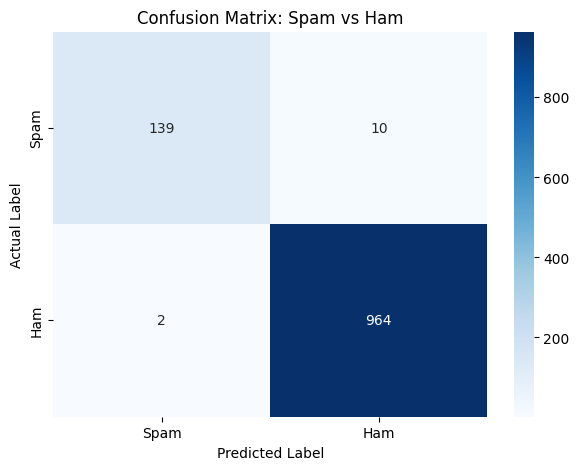

In [137]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Spam', 'Ham'],
    yticklabels=['Spam', 'Ham']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Spam vs Ham')

plt.show()

In [138]:
# Save the best trained pipeline

model_filename = 'advanced_spam_classifier.joblib'

joblib.dump(best_model, model_filename)

print("Model successfully saved as:", model_filename)

Model successfully saved as: advanced_spam_classifier.joblib


In [139]:
# Test the upgraded model with new emails

custom_emails = [
    "URGENT: Your bank account has been locked. Click here to verify your identity.",
    "Hey, are we still on for lunch tomorrow at 12?"
]

predictions = best_model.predict(custom_emails)

for text, pred in zip(custom_emails, predictions):
    label = "Ham" if pred == 1 else "Spam"
    print(f"[{label}] - {text}")

[Ham] - URGENT: Your bank account has been locked. Click here to verify your identity.
[Ham] - Hey, are we still on for lunch tomorrow at 12?
